In [6]:
import glob
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define the directory where your files are located
csv_directory = '/content/sample_data/'

# Use glob to find all XLSX files in the directory
csv_files = glob.glob(csv_directory + '*.xlsx')

# Create an empty list to store individual DataFrames
list_df = []

# Loop through each XLSX file, read it using pd.read_excel(), and append to the list
for file in csv_files:
    try:
        df_temp = pd.read_excel(file)
        list_df.append(df_temp)
        print(f"Successfully read: {file}")
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames in the list into a single DataFrame
if list_df:
    combined_df = pd.concat(list_df, ignore_index=True)
    print(f"\nCombined DataFrame has {len(combined_df)} rows and {len(combined_df.columns)} columns.")
    display(combined_df.head())
else:
    print("No XLSX files were read or combined.")

Successfully read: /content/sample_data/PGEN.xlsx
Successfully read: /content/sample_data/PTGO.xlsx
Successfully read: /content/sample_data/PZAM.xlsx
Successfully read: /content/sample_data/PTCG.xlsx
Successfully read: /content/sample_data/PMRM.xlsx
Successfully read: /content/sample_data/PCOT.xlsx
Successfully read: /content/sample_data/PMAI.xlsx
Successfully read: /content/sample_data/PDIP.xlsx
Successfully read: /content/sample_data/PSUR.xlsx
Successfully read: /content/sample_data/DVAO.xlsx
Successfully read: /content/sample_data/PDAV.xlsx
Successfully read: /content/sample_data/PBIS.xlsx
Successfully read: /content/sample_data/PDDN.xlsx

Combined DataFrame has 7395 rows and 23 columns.


,site,YYMMMDD,yyyy.yyyy,__MJD,week,d,reflon,_e0(m),__east(m),____n0(m),...,_ant(m),sig_e(m),sig_n(m),sig_u(m),__corr_en,__corr_eu,__corr_nu,_latitude(deg),_longitude(deg),__height(m)
0,PGEN,2012-09-10,2010.6968,55451,1601,0,125.1,3505,0.051420,670648,...,0.0,0.000781,0.000705,0.002822,-0.042551,0.051493,0.003388,6.064913,-234.868338,121.12038
1,PGEN,2013-09-10,2010.6995,55452,1601,1,125.1,3505,0.052779,670648,...,0.0,0.000776,0.000696,0.002937,-0.094832,0.042616,0.007115,6.064913,-234.868338,121.13173
2,PGEN,2014-09-10,2010.7023,55453,1601,2,125.1,3505,0.053321,670648,...,0.0,0.000751,0.000690,0.002765,-0.064193,0.029360,-0.002403,6.064913,-234.868338,121.12611
3,PGEN,2015-09-10,2010.7050,55454,1601,3,125.1,3505,0.053074,670648,...,0.0,0.000776,0.000694,0.002942,-0.058500,0.021269,0.017934,6.064913,-234.868338,121.12209
4,PGEN,2016-09-10,2010.7077,55455,1601,4,125.1,3505,0.053121,670648,...,0.0,0.000793,0.000724,0.003128,-0.060036,-0.026641,0.028853,6.064913,-234.868338,121.12436


COLUMNS:
Index(['site', 'yymmmdd', 'yyyyyyyy', 'mjd', 'week', 'd', 'reflon', 'e0',
       'east', 'n0', 'north', 'u0', 'up', 'ant', 'sig_e', 'sig_n', 'sig_u',
       'corr_en', 'corr_eu', 'corr_nu', 'latitude', 'longitude', 'height'],
      dtype='object')

AFTER OUTLIER REMOVAL: (7395, 26)

PREPROCESSED DATA:


,site,yyyyyyyy,mjd,week,d,reflon,e0,east,n0,north,...,corr_nu,latitude,longitude,height,time,year,month,day,east_smooth,north_smooth
3507,PSUR,2015.0007,57023,1825,4,125.5,-691,-0.429631,1082827,0.473123,...,0.009945,9.791809,-234.506302,80.29021,2001-01-15,2001,1,15,-0.429631,0.473123
2653,PZAM,2015.0007,57023,1825,4,122.1,-3863,-0.307698,766167,0.836714,...,0.066511,6.928650,-237.934958,84.22153,2001-01-15,2001,1,15,-0.307698,0.836714
2373,PTGO,2015.0007,57023,1825,4,124.8,-4951,-0.106679,942817,0.335487,...,-0.029340,8.525923,-235.244970,93.13321,2001-01-15,2001,1,15,-0.028170,0.436652
7010,PDAV,2015.0007,57023,1825,4,125.6,4794,0.712680,788047,0.153154,...,-0.002945,7.126490,-234.356595,98.86645,2001-01-15,2001,1,15,0.226448,0.370536
382,PGEN,2016.0000,57388,1877,5,125.1,3505,-0.009523,670648,0.384781,...,0.058298,6.064912,-234.868338,121.11719,2001-01-16,2001,1,16,0.283317,0.278207



SCALED FEATURES:


,east_smooth,north_smooth,north
0,-3.088549,1.194261,0.722444
1,-2.532820,3.878786,2.346130
2,-1.258827,0.924981,0.107803
3,-0.098365,0.436827,-0.706440
4,0.160827,-0.244873,0.327935


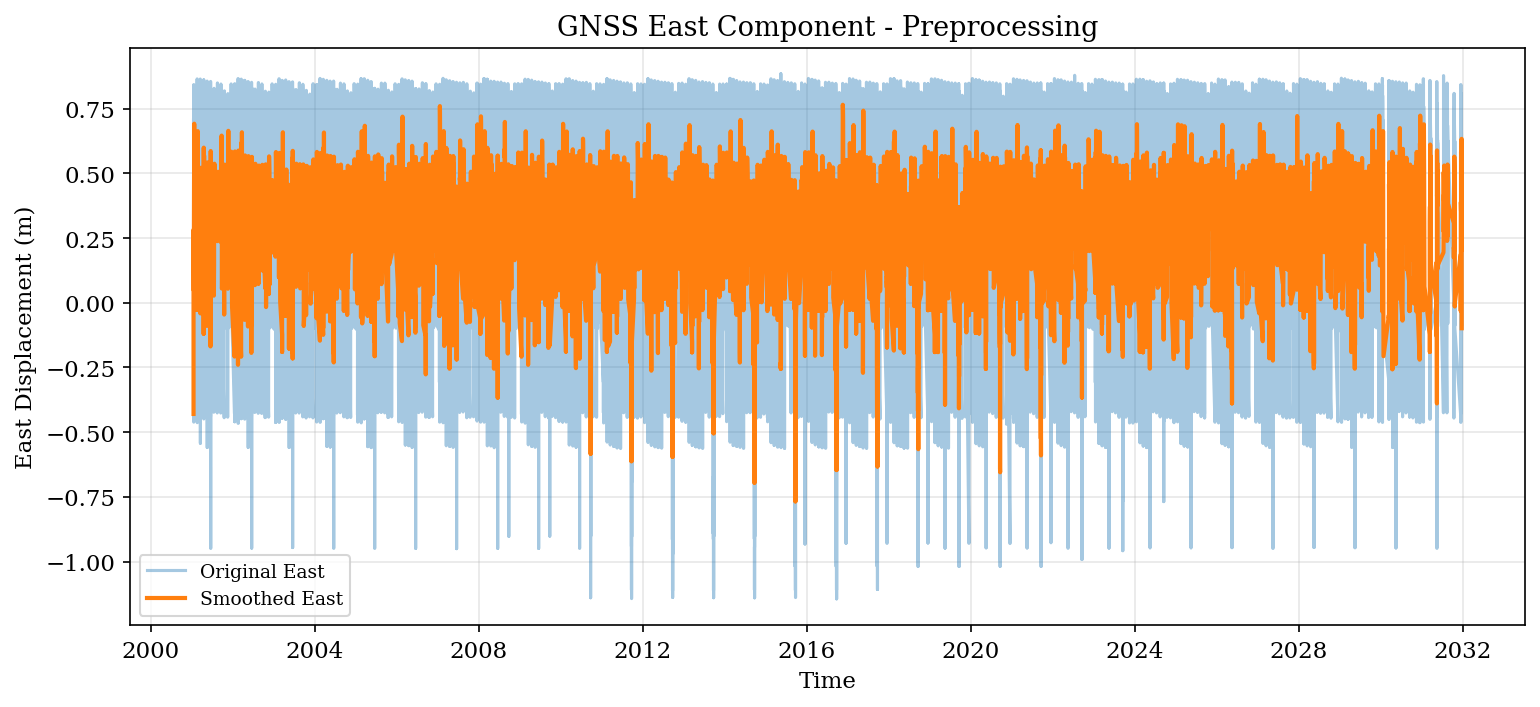


Saved: preprocessed_gnss_data.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy import stats

# =========================
# 1. COPY DATAFRAME
# =========================
df = combined_df.copy()

# =========================
# 2. CLEAN COLUMN NAMES
# =========================
df.columns = df.columns.str.strip().str.lower()

new_columns = []
for col in df.columns:
    col = col.replace('__', '')
    col = col.replace('(m)', '')
    col = col.replace('(deg)', '')
    col = col.replace('.', '')
    col = col.strip('_')
    new_columns.append(col)

df.columns = new_columns

print("COLUMNS:")
print(df.columns)

# =========================
# 3. REMOVE DUPLICATES
# =========================
df = df.drop_duplicates()

# =========================
# 4. HANDLE MISSING VALUES
# =========================
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

df = df.dropna()

# =========================
# 5. CONVERT TIME
# =========================
if 'yymmmdd' in df.columns:
    df['time'] = pd.to_datetime(df['yymmmdd'], errors='coerce')

    df['year'] = df['time'].dt.year
    df['month'] = df['time'].dt.month
    df['day'] = df['time'].dt.day

    df = df.drop(columns=['yymmmdd'])

# =========================
# 6. OUTLIER DETECTION (Z-SCORE)
# =========================
z_east = np.abs(stats.zscore(df['east']))
z_north = np.abs(stats.zscore(df['north']))

threshold = 3

df = df[(z_east < threshold) & (z_north < threshold)]

print("\nAFTER OUTLIER REMOVAL:", df.shape)

# =========================
# 7. SORT BY TIME
# =========================
df = df.sort_values(by='time')

# =========================
# 8. SMOOTHING (MOVING AVERAGE)
# =========================
window_size = 5

df['east_smooth'] = df['east'].rolling(window=window_size, center=True).mean()
df['north_smooth'] = df['north'].rolling(window=window_size, center=True).mean()

df['east_smooth'] = df['east_smooth'].fillna(df['east'])
df['north_smooth'] = df['north_smooth'].fillna(df['north'])

# =========================
# 9. FEATURE SELECTION
# =========================
target_column = 'east'

# use smoothed version for better ML performance
X = df[['time', 'east_smooth', 'north_smooth', 'north']]
y = df[target_column]

# =========================
# 10. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df[['east_smooth', 'north_smooth', 'north']]
)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=['east_smooth', 'north_smooth', 'north']
)

# =========================
# 11. FINAL OUTPUT
# =========================
print("\nPREPROCESSED DATA:")
display(df.head())

print("\nSCALED FEATURES:")
display(X_scaled.head())

# =========================
# 12. VISUALIZATION
# =========================
plt.figure(figsize=(12,5))

plt.plot(df['time'], df['east'], label='Original East', alpha=0.4)
plt.plot(df['time'], df['east_smooth'], label='Smoothed East', linewidth=2)

plt.xlabel("Time")
plt.ylabel("East Displacement (m)")
plt.title("GNSS East Component - Preprocessing")
plt.legend()
plt.show()

# =========================
# 13. SAVE DATASET
# =========================
df.to_csv("preprocessed_gnss_data.csv", index=False)

print("\nSaved: preprocessed_gnss_data.csv")

BLOCK 1 — INSTALL DEPENDENCIES


In [8]:
# ============================================================
# GNSS THESIS — COMPLETE COLAB CODE BLOCKS
# Copy each block into a separate Colab cell in order.
#
# Cleaned column names used throughout (from your notebook):
#   site, time, year, month, day
#   mjd, week, d, reflon
#   e0, east, n0, north, u0, up, ant
#   sig_e, sig_u
#   corr_en, corr_eu, corr_nu
#   latitude, longitude, height
#   east_smooth, north_smooth  (created in preprocessing)
# ============================================================

 BLOCK 2 — IMPORTS & GLOBAL SETTINGS

In [9]:
!pip install pykrige --quiet
!pip install scikit-learn --upgrade --quiet

In [10]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# Sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyKrige
try:
    from pykrige.ok import OrdinaryKriging
    PYKRIGE_AVAILABLE = True
    print("PyKrige loaded successfully.")
except ImportError:
    PYKRIGE_AVAILABLE = False
    print("PyKrige not found — IDW will be used as fallback.")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Thesis-style plots
plt.rcParams.update({
    'figure.dpi'     : 150,
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
    'legend.fontsize': 9,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'figure.facecolor': 'white',
})

MODEL_COLORS = {
    'Random Forest': '#2196F3',
    'SVR'          : '#FF9800',
    'LSTM'         : '#4CAF50',
}

print("All imports done.")
print(f"TensorFlow version : {tf.__version__}")

PyKrige loaded successfully.
All imports done.
TensorFlow version : 2.20.0


BLOCK 3 — PHASE 1: LOAD PREPROCESSED DATA
                                   
This block expects 'preprocessed_gnss_data.csv'
which was already saved by your preprocessing notebook.
All columns are already cleaned and time is parsed.

In [11]:
# ── Load ──────────────────────────────────────────────────────
df = pd.read_csv("preprocessed_gnss_data.csv")

# ── Ensure time column is datetime ────────────────────────────
df['time'] = pd.to_datetime(df['time'], errors='coerce')

# ── Add year/month/day if not already present ──────────────────
if 'year' not in df.columns:
    df['year']  = df['time'].dt.year
if 'month' not in df.columns:
    df['month'] = df['time'].dt.month
if 'day' not in df.columns:
    df['day']   = df['time'].dt.day

# ── Drop rows missing critical columns ─────────────────────────
required = ['site', 'time', 'east', 'north', 'up', 'latitude', 'longitude']
df = df.dropna(subset=required)
df = df.drop_duplicates()

# ── Sort by station then time ──────────────────────────────────
df = df.sort_values(['site', 'time']).reset_index(drop=True)

print("=" * 55)
print("PHASE 1 — DATA LOADED")
print("=" * 55)
print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"Sites   : {df['site'].nunique()}")
print(f"Date range : {df['time'].min().date()} → {df['time'].max().date()}")
print()
print(df[['east', 'north', 'up', 'latitude', 'longitude']].describe().round(6))

PHASE 1 — DATA LOADED
Shape   : (7395, 28)
Columns : ['site', 'yyyyyyyy', 'mjd', 'week', 'd', 'reflon', 'e0', 'east', 'n0', 'north', 'u0', 'up', 'ant', 'sig_e', 'sig_n', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu', 'latitude', 'longitude', 'height', 'time', 'year', 'month', 'day', 'east_smooth', 'north_smooth']
Sites   : 13
Date range : 2001-01-15 → 2031-12-24

              east        north           up     latitude    longitude
count  7395.000000  7395.000000  7395.000000  7395.000000  7395.000000
mean      0.248033     0.311347     0.521552     7.122211  -234.804743
std       0.479951     0.223944     0.406580     1.095472     0.774757
min      -1.144275     0.044973     0.061172     6.061264  -237.934958
25%      -0.089112     0.117178     0.107715     6.064912  -234.868339
50%      -0.000510     0.285542     0.299092     7.071865  -234.506303
75%       0.688586     0.385396     0.971607     7.071865  -234.387131
max       0.885038     0.939385     2.570764     9.791813  -233.646119


BLOCK 4 — PHASE 2: VELOCITY COMPUTATION          
                                                          
  Ve = ΔEast  / Δt                                       
  Vn = ΔNorth / Δt                                           
  Vu = ΔUp    / Δt       (Δt in decimal years)               
                                                              
Per-station robust median velocity is used as the          representative velocity, resistant to offsets/outliers.

In [13]:
DAYS_PER_YEAR = 365.25
records = []

for site_id, grp in df.groupby('site'):
    grp = grp.sort_values('time').reset_index(drop=True)
    if len(grp) < 2:
        continue                                   # skip single-epoch stations

    # Δt in decimal years
    if 'mjd' in grp.columns and grp['mjd'].notna().all():
        dt_yr = grp['mjd'].diff() / DAYS_PER_YEAR
    else:
        dt_days = grp['time'].diff().dt.total_seconds() / 86400.0
        dt_yr   = dt_days / DAYS_PER_YEAR

    # Finite-difference velocity components
    ve_series = grp['east'].diff()  / dt_yr
    vn_series = grp['north'].diff() / dt_yr
    vu_series = grp['up'].diff()    / dt_yr

    # Median velocity per station (robust estimator)
    Ve = float(np.nanmedian(ve_series.dropna()))
    Vn = float(np.nanmedian(vn_series.dropna()))
    Vu = float(np.nanmedian(vu_series.dropna()))

    # Collect station metadata
    row = {
        'site'     : site_id,
        'latitude' : grp['latitude'].median(),
        'longitude': grp['longitude'].median(),
        'height'   : pd.to_numeric(grp['height'], errors='coerce').median()   if 'height'   in grp else np.nan,
        'mjd'      : grp['mjd'].median()      if 'mjd'      in grp else np.nan,
        'week'     : grp['week'].median()     if 'week'     in grp else np.nan,
        'sig_e'    : grp['sig_e'].median()    if 'sig_e'    in grp else np.nan,
        'sig_u'    : grp['sig_u'].median()    if 'sig_u'    in grp else np.nan,
        'corr_en'  : grp['corr_en'].median()  if 'corr_en'  in grp else np.nan,
        'corr_eu'  : grp['corr_eu'].median()  if 'corr_eu'  in grp else np.nan,
        'corr_nu'  : grp['corr_nu'].median()  if 'corr_nu'  in grp else np.nan,
        'n_epochs' : len(grp),
        'Ve'       : Ve,
        'Vn'       : Vn,
        'Vu'       : Vu,
    }
    records.append(row)

vel_df = pd.DataFrame(records).dropna(subset=['Ve', 'Vn', 'Vu'])
vel_df = vel_df.reset_index(drop=True)

vel_df.to_csv("gnss_station_velocities.csv", index=False)

print("=" * 55)
print("PHASE 2 — VELOCITY COMPUTATION COMPLETE")
print("=" * 55)
print(f"Stations with computed velocities : {len(vel_df)}")
print()
print("Velocity statistics [m/yr]:")
print(vel_df[['Ve', 'Vn', 'Vu']].describe().round(6))
print()
print("Saved: gnss_station_velocities.csv")
display(vel_df.head(10))

PHASE 2 — VELOCITY COMPUTATION COMPLETE
Stations with computed velocities : 13

Velocity statistics [m/yr]:
              Ve         Vn         Vu
count  13.000000  13.000000  13.000000
mean   -0.026584  -0.042574  -0.074907
std     0.040730   0.154315   0.263299
min    -0.155414  -0.554815  -0.951111
25%    -0.028949  -0.009260  -0.004509
50%    -0.017386  -0.001656  -0.001030
75%    -0.010649   0.000581   0.000915
max     0.015700   0.027194   0.003937

Saved: gnss_station_velocities.csv


,site,latitude,longitude,height,mjd,week,sig_e,sig_u,corr_en,corr_eu,corr_nu,n_epochs,Ve,Vn,Vu
0,DVAO,7.071865,-234.387132,99.976615,59072.5,2118.0,0.000857,0.003288,-0.009087,0.069767,0.043024,2980,-0.027744,-0.004182,-0.002869
1,PBIS,8.189172,-233.646119,80.345030,58018.0,1967.0,0.000812,0.003018,0.009859,0.017497,0.073017,71,-0.030673,0.018406,-0.001030
2,PCOT,7.199604,-235.752967,86.170590,57853.0,1944.0,0.000927,0.003533,-0.003435,-0.057709,0.074945,125,-0.010649,-0.009260,0.000915
3,PDAV,7.126490,-234.356595,98.868370,57157.0,1844.0,0.000875,0.003467,0.009643,0.056285,-0.002543,265,-0.030390,-0.001656,-0.004509
4,PDDN,7.459377,-234.216750,90.574670,59108.0,2123.0,0.000889,0.003407,0.019573,0.003445,0.040750,49,-0.028949,0.000545,-0.011117
5,PDIP,8.586842,-236.655707,88.426830,57482.0,1891.0,0.000828,0.003208,-0.016410,0.003514,0.043003,211,-0.006614,0.000877,0.002386
6,PGEN,6.064912,-234.868338,121.095380,58444.0,2028.0,0.000879,0.003379,0.007349,0.032426,0.073876,2373,-0.010057,-0.010548,-0.003733
7,PMAI,6.061264,-235.504403,92.392390,59836.0,2227.0,0.001280,0.005088,0.051251,-0.047629,-0.116126,7,-0.155414,-0.554815,-0.951111
8,PMRM,7.856279,-234.941257,375.538800,59835.5,2227.0,0.000941,0.003753,-0.011470,-0.029302,-0.034950,22,-0.017386,-0.000644,0.003937
9,PSUR,9.791809,-234.506303,80.289880,57274.5,1861.0,0.000843,0.003271,-0.043166,0.053549,0.036328,714,-0.019155,0.027194,-0.007292


 BLOCK 5 — PHASE 3: FEATURE ENGINEERING       

In [14]:
 # ── Encode site IDs as integers ────────────────────────────────
le = LabelEncoder()
vel_df['site_encoded'] = le.fit_transform(vel_df['site'].astype(str))

# ── Define feature columns (use what exists in the dataset) ────
all_feature_cols = [
    'latitude', 'longitude', 'height',
    'mjd', 'week',
    'sig_e', 'sig_u',
    'corr_en', 'corr_eu', 'corr_nu',
    'site_encoded',
]
feature_cols = [c for c in all_feature_cols if c in vel_df.columns]

X = vel_df[feature_cols].copy()
y = vel_df[['Ve', 'Vn', 'Vu']].copy()

# Fill residual NaNs with column median
X = X.fillna(X.median(numeric_only=True))

# Fit StandardScaler (required by SVR and LSTM)
scaler = StandardScaler()
scaler.fit(X)

print("=" * 55)
print("PHASE 3 — FEATURE ENGINEERING COMPLETE")
print("=" * 55)
print(f"Feature matrix shape : {X.shape}")
print(f"Feature columns      : {feature_cols}")
print(f"Target columns       : {list(y.columns)}")
print()
display(X.describe().round(4))

PHASE 3 — FEATURE ENGINEERING COMPLETE
Feature matrix shape : (13, 11)
Feature columns      : ['latitude', 'longitude', 'height', 'mjd', 'week', 'sig_e', 'sig_u', 'corr_en', 'corr_eu', 'corr_nu', 'site_encoded']
Target columns       : ['Ve', 'Vn', 'Vu']



,latitude,longitude,height,mjd,week,sig_e,sig_u,corr_en,corr_eu,corr_nu,site_encoded
count,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000,13.0000
mean,7.5043,-235.1799,117.2908,58390.4231,2020.4615,0.0009,0.0037,-0.0051,-0.0116,0.0220,6.0000
std,1.0649,1.1336,79.1424,1067.1698,152.5050,0.0001,0.0007,0.0280,0.0783,0.0560,3.8944
min,6.0613,-237.9350,80.2899,57157.0000,1844.0000,0.0008,0.0030,-0.0586,-0.2314,-0.1161,0.0000
25%,6.9286,-235.5044,86.1706,57482.0000,1891.0000,0.0008,0.0033,-0.0164,-0.0476,-0.0025,3.0000
50%,7.1996,-234.9413,92.3924,58018.0000,1967.0000,0.0009,0.0034,-0.0034,0.0035,0.0408,6.0000
75%,8.1892,-234.3871,99.9766,59108.0000,2123.0000,0.0009,0.0038,0.0096,0.0324,0.0610,9.0000
max,9.7918,-233.6461,375.5388,60018.0000,2253.0000,0.0013,0.0051,0.0513,0.0698,0.0749,12.0000


BLOCK 6 — PHASE 4: DATA SPLITTING  (70 / 15 / 15)

In [15]:
# First split: 85% trainval, 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE)

# Second split: from 85%, take ~17.6% → final 15% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=(0.15 / 0.85),
    random_state=RANDOM_STATE)

n_total = len(X)
print("=" * 55)
print("PHASE 4 — DATA SPLITTING")
print("=" * 55)
print(f"  Total samples  : {n_total}")
print(f"  Training       : {len(X_train):>4}  ({len(X_train)/n_total*100:.1f}%)")
print(f"  Validation     : {len(X_val):>4}  ({len(X_val)/n_total*100:.1f}%)")
print(f"  Test           : {len(X_test):>4}  ({len(X_test)/n_total*100:.1f}%)")

PHASE 4 — DATA SPLITTING
  Total samples  : 13
  Training       :    9  (69.2%)
  Validation     :    2  (15.4%)
  Test           :    2  (15.4%)


BLOCK 7 — PHASE 5a: RANDOM FOREST

PHASE 5a — RANDOM FOREST REGRESSOR

Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.

  OOB R²         : -0.3227
  Validation R²  : -3793.1731

  Feature Importances:
corr_en         0.1747
sig_e           0.1166
longitude       0.0983
latitude        0.0977
mjd             0.0927
corr_nu         0.0887
site_encoded    0.0825
week            0.0728
sig_u           0.0716
corr_eu         0.0712
height          0.0333


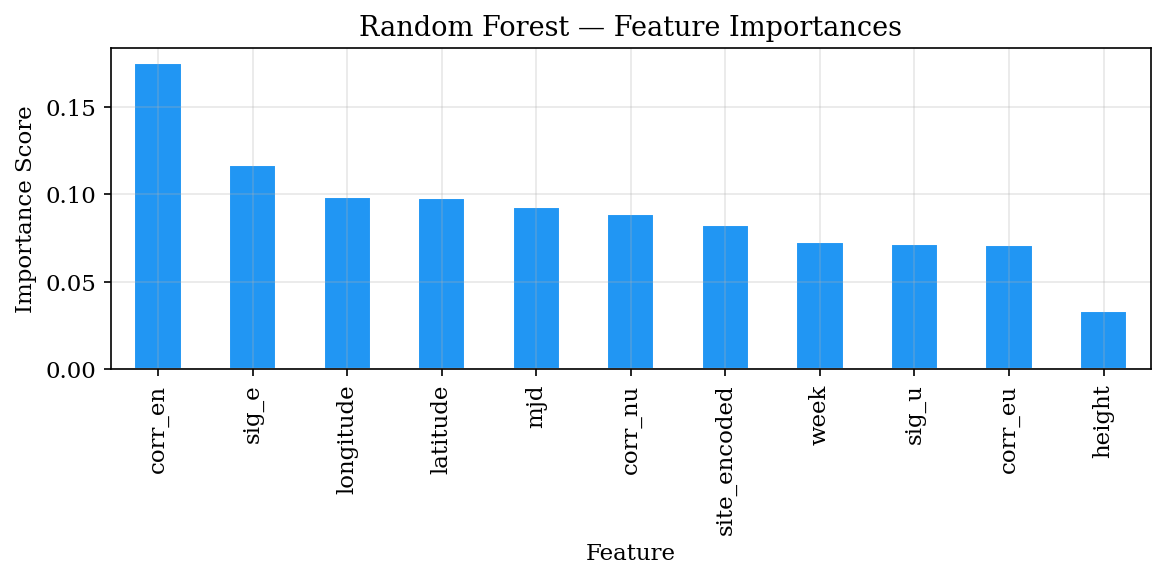

Saved: rf_feature_importance.png


In [16]:
print("=" * 55)
print("PHASE 5a — RANDOM FOREST REGRESSOR")
print("=" * 55)
print("""
Why Random Forest?
  Ensemble of decision trees on bootstrapped subsets.
  Handles non-linear velocity patterns across station networks.
  Built-in feature importance has geodetic interpretability.
  Robust to noisy/outlier GNSS observations.
""")

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_model.fit(X_train, y_train)

# OOB and validation check
rf_oob    = rf_model.oob_score_
rf_val    = rf_model.predict(X_val)
rf_val_r2 = r2_score(y_val, rf_val)

print(f"  OOB R²         : {rf_oob:.4f}")
print(f"  Validation R²  : {rf_val_r2:.4f}")

# Feature importances
importances = pd.Series(
    rf_model.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("\n  Feature Importances:")
print(importances.round(4).to_string())

# Plot feature importance
fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='white')
ax.set_title("Random Forest — Feature Importances")
ax.set_ylabel("Importance Score")
ax.set_xlabel("Feature")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rf_feature_importance.png")

BLOCK 8 — PHASE 5b: SUPPORT VECTOR REGRESSION (SVR)

In [17]:
print("=" * 55)
print("PHASE 5b — SUPPORT VECTOR REGRESSION (SVR)")
print("=" * 55)
print("""
Why SVR?
  Finds a regression hyperplane in RBF kernel space.
  Insensitive to errors within epsilon tube.
  Captures smooth non-linear velocity gradients.
  Appropriate for regionally correlated GNSS networks.
  NOTE: features MUST be z-score normalised.
""")

# Scale features
Xs_train = scaler.transform(X_train)
Xs_val   = scaler.transform(X_val)
Xs_test  = scaler.transform(X_test)

# One SVR per velocity component (sklearn SVR is single-output)
svr_models = {}
for comp in ['Ve', 'Vn', 'Vu']:
    svr = SVR(
        kernel='rbf',
        C=10.0,
        epsilon=0.001,
        gamma='scale',
    )
    svr.fit(Xs_train, y_train[comp])
    val_pred = svr.predict(Xs_val)
    r2       = r2_score(y_val[comp], val_pred)
    print(f"  SVR {comp} — Validation R²: {r2:.4f}")
    svr_models[comp] = svr

print("\n  SVR training complete.")

PHASE 5b — SUPPORT VECTOR REGRESSION (SVR)

Why SVR?
  Finds a regression hyperplane in RBF kernel space.
  Insensitive to errors within epsilon tube.
  Captures smooth non-linear velocity gradients.
  Appropriate for regionally correlated GNSS networks.
  NOTE: features MUST be z-score normalised.

  SVR Ve — Validation R²: -2.6728
  SVR Vn — Validation R²: -355.2782
  SVR Vu — Validation R²: -16495.6799

  SVR training complete.


 BLOCK 9 — PHASE 5c: LSTM NEURAL NETWORK  

PHASE 5c — LSTM NEURAL NETWORK

Why LSTM?
  GNSS displacements have temporal autocorrelation from seasonal
  loading, tectonic transients, and postseismic relaxation.
  LSTM gates (input/forget/output) learn multi-scale time dependencies.
  More expressive than classical regression for velocity estimation.
 
Architecture:
  Input → LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2)
        → Dense(16, relu) → Dense(3)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,451 (126.76 KB)

 Trainable params: 32,451 (126.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.0473 - mae: 0.0767 - val_loss: 3.0111e-04 - val_mae: 0.0128 - learning_rate: 0.0010
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0472 - mae: 0.0731 - val_loss: 2.6142e-04 - val_mae: 0.0124 - learning_rate: 0.0010
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.0459 - mae: 0.0727 - val_loss: 2.3605e-04 - val_mae: 0.0122 - learning_rate: 0.0010
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0444 - mae: 0.0692 - val_loss: 2.1478e-04 - val_mae: 0.0118 - learning_rate: 0.0010
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0435 - mae: 0.0693 - val_loss: 2.0081e-04 - val_mae: 0.0116 - learning_rate: 0.0010
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0439 - mae: 0.0710 - val_loss: 1.9031e-04 - val_mae: 0.0113 - learning_rate: 0.0010
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0431 - mae: 0.0690 - val_loss: 1.8622e-04 - val_mae: 0.0112 - learning_r

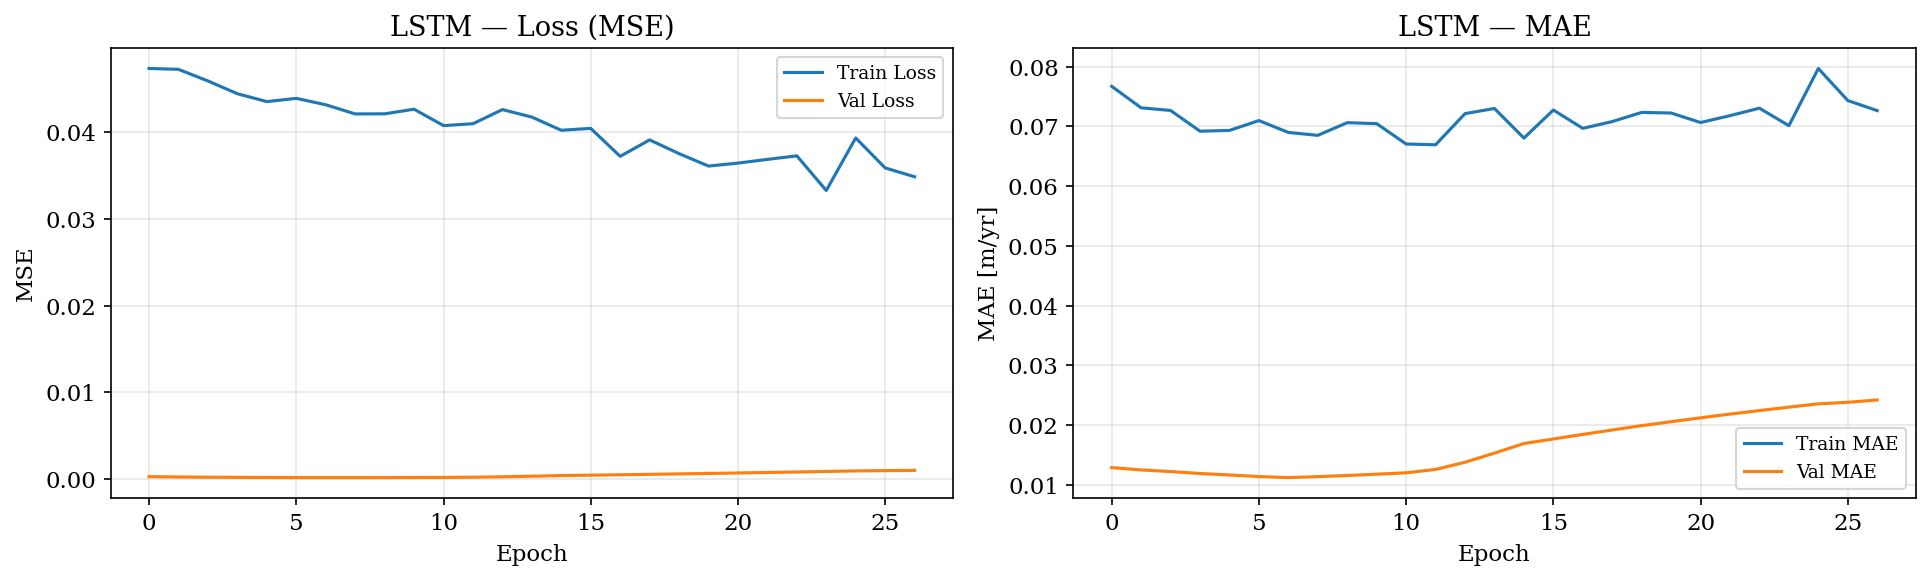

Saved: lstm_training_curves.png


In [18]:
print("=" * 55)
print("PHASE 5c — LSTM NEURAL NETWORK")
print("=" * 55)
print("""
Why LSTM?
  GNSS displacements have temporal autocorrelation from seasonal
  loading, tectonic transients, and postseismic relaxation.
  LSTM gates (input/forget/output) learn multi-scale time dependencies.
  More expressive than classical regression for velocity estimation.

Architecture:
  Input → LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2)
        → Dense(16, relu) → Dense(3)
""")

# Scale and reshape to (samples, timesteps=1, features)
Xs_train_3d = Xs_train.reshape((Xs_train.shape[0], 1, Xs_train.shape[1]))
Xs_val_3d   = Xs_val.reshape((Xs_val.shape[0],   1, Xs_val.shape[1]))
Xs_test_3d  = Xs_test.reshape((Xs_test.shape[0],  1, Xs_test.shape[1]))

n_features = Xs_train.shape[1]

lstm_model = Sequential([
    Input(shape=(1, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3),                       # outputs: Ve, Vn, Vu
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)
lstm_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
]

history = lstm_model.fit(
    Xs_train_3d, y_train.values,
    validation_data=(Xs_val_3d, y_val.values),
    epochs=200,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title("LSTM — Loss (MSE)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title("LSTM — MAE")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE [m/yr]")
axes[1].legend()

plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lstm_training_curves.png")

BLOCK 10 — PHASE 6: REGRESSION EVALUATION

In [19]:
print("=" * 55)
print("PHASE 6 — REGRESSION EVALUATION (Test Set)")
print("=" * 55)

components = ['Ve', 'Vn', 'Vu']
rows = []
predictions = {}   # {model_name: ndarray shape (n_test, 3)}

# ── Random Forest ──────────────────────────────────────────────
rf_pred = rf_model.predict(X_test)
predictions['Random Forest'] = rf_pred

# ── SVR ────────────────────────────────────────────────────────
svr_pred = np.column_stack([svr_models[c].predict(Xs_test)
                            for c in components])
predictions['SVR'] = svr_pred

# ── LSTM ───────────────────────────────────────────────────────
lstm_pred = lstm_model.predict(Xs_test_3d, verbose=0)
predictions['LSTM'] = lstm_pred

# ── Compute metrics ────────────────────────────────────────────
for model_name, pred_arr in predictions.items():
    for i, comp in enumerate(components):
        actual = y_test[comp].values
        pred   = pred_arr[:, i]
        rows.append({
            'Model'    : model_name,
            'Component': comp,
            'RMSE'     : round(np.sqrt(mean_squared_error(actual, pred)), 7),
            'MAE'      : round(mean_absolute_error(actual, pred), 7),
            'R²'       : round(r2_score(actual, pred), 4),
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("regression_metrics.csv", index=False)

print("\nRegression Metrics:")
display(metrics_df)
print("Saved: regression_metrics.csv")

PHASE 6 — REGRESSION EVALUATION (Test Set)

Regression Metrics:


,Model,Component,RMSE,MAE,R²
0,Random Forest,Ve,0.012016,0.010229,-9.0624
1,Random Forest,Vn,0.044961,0.044903,-10.4168
2,Random Forest,Vu,0.057163,0.049781,-285.2168
3,SVR,Ve,0.014503,0.014319,-13.6605
4,SVR,Vn,0.067207,0.065209,-24.5102
5,SVR,Vu,0.086786,0.086633,-658.7366
6,LSTM,Ve,0.014496,0.011786,-13.6454
7,LSTM,Vn,0.008136,0.008128,0.6262
8,LSTM,Vu,0.010676,0.009307,-8.9831


Saved: regression_metrics.csv


BLOCK 11 — PHASE 6 PLOTS: ACTUAL VS ESTIMATED  

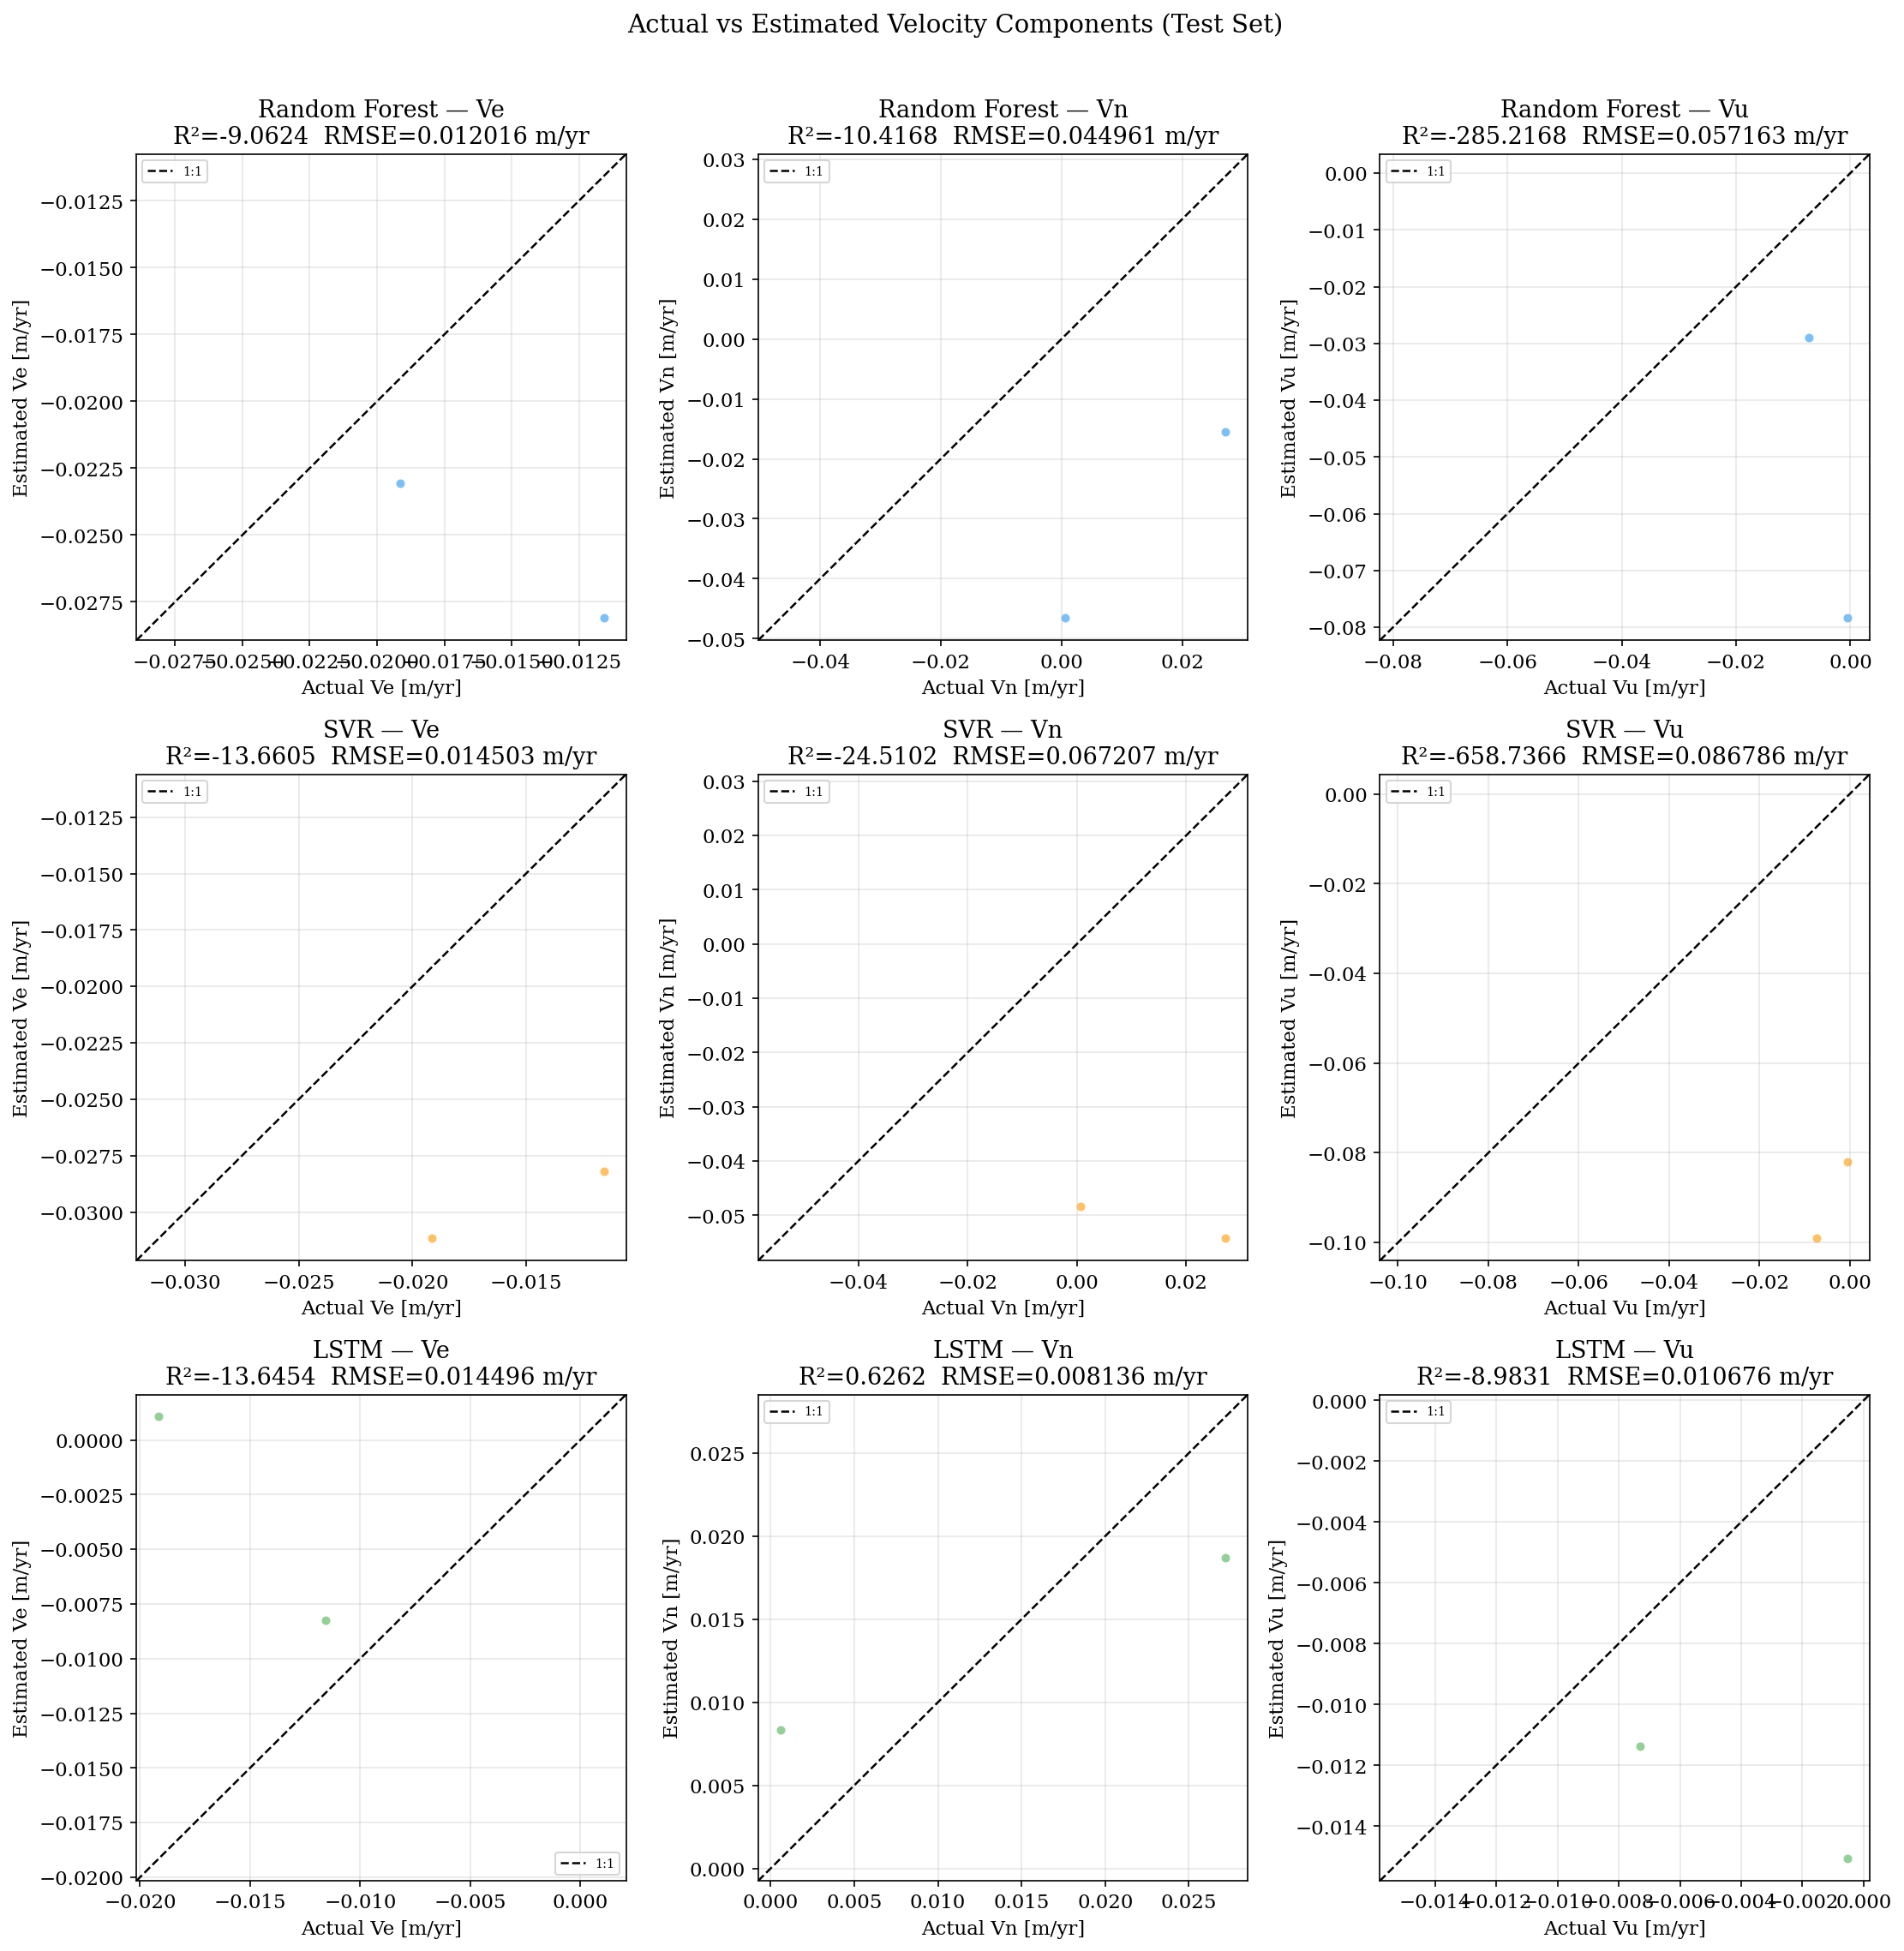

Saved: actual_vs_estimated.png


In [20]:
model_names = list(predictions.keys())
n_models    = len(model_names)

fig, axes = plt.subplots(n_models, 3, figsize=(15, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax     = axes[row_i][col_i]
        actual = y_test[comp].values
        pred   = pred_arr[:, col_i]

        mrow = metrics_df[(metrics_df['Model'] == model_name) &
                          (metrics_df['Component'] == comp)]
        r2   = mrow['R²'].values[0]
        rmse = mrow['RMSE'].values[0]

        ax.scatter(actual, pred, alpha=0.6, s=25, color=color,
                   edgecolors='white', lw=0.3)
        lo = min(actual.min(), pred.min())
        hi = max(actual.max(), pred.max())
        margin = (hi - lo) * 0.05
        ax.plot([lo - margin, hi + margin],
                [lo - margin, hi + margin], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(lo - margin, hi + margin)
        ax.set_ylim(lo - margin, hi + margin)
        ax.set_xlabel(f"Actual {comp} [m/yr]")
        ax.set_ylabel(f"Estimated {comp} [m/yr]")
        ax.set_title(f"{model_name} — {comp}\nR²={r2:.4f}  RMSE={rmse:.6f} m/yr")
        ax.legend(fontsize=7)

fig.suptitle("Actual vs Estimated Velocity Components (Test Set)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("actual_vs_estimated.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: actual_vs_estimated.png")

BLOCK 12 — PHASE 6 PLOTS: RESIDUAL DISTRIBUTIONS

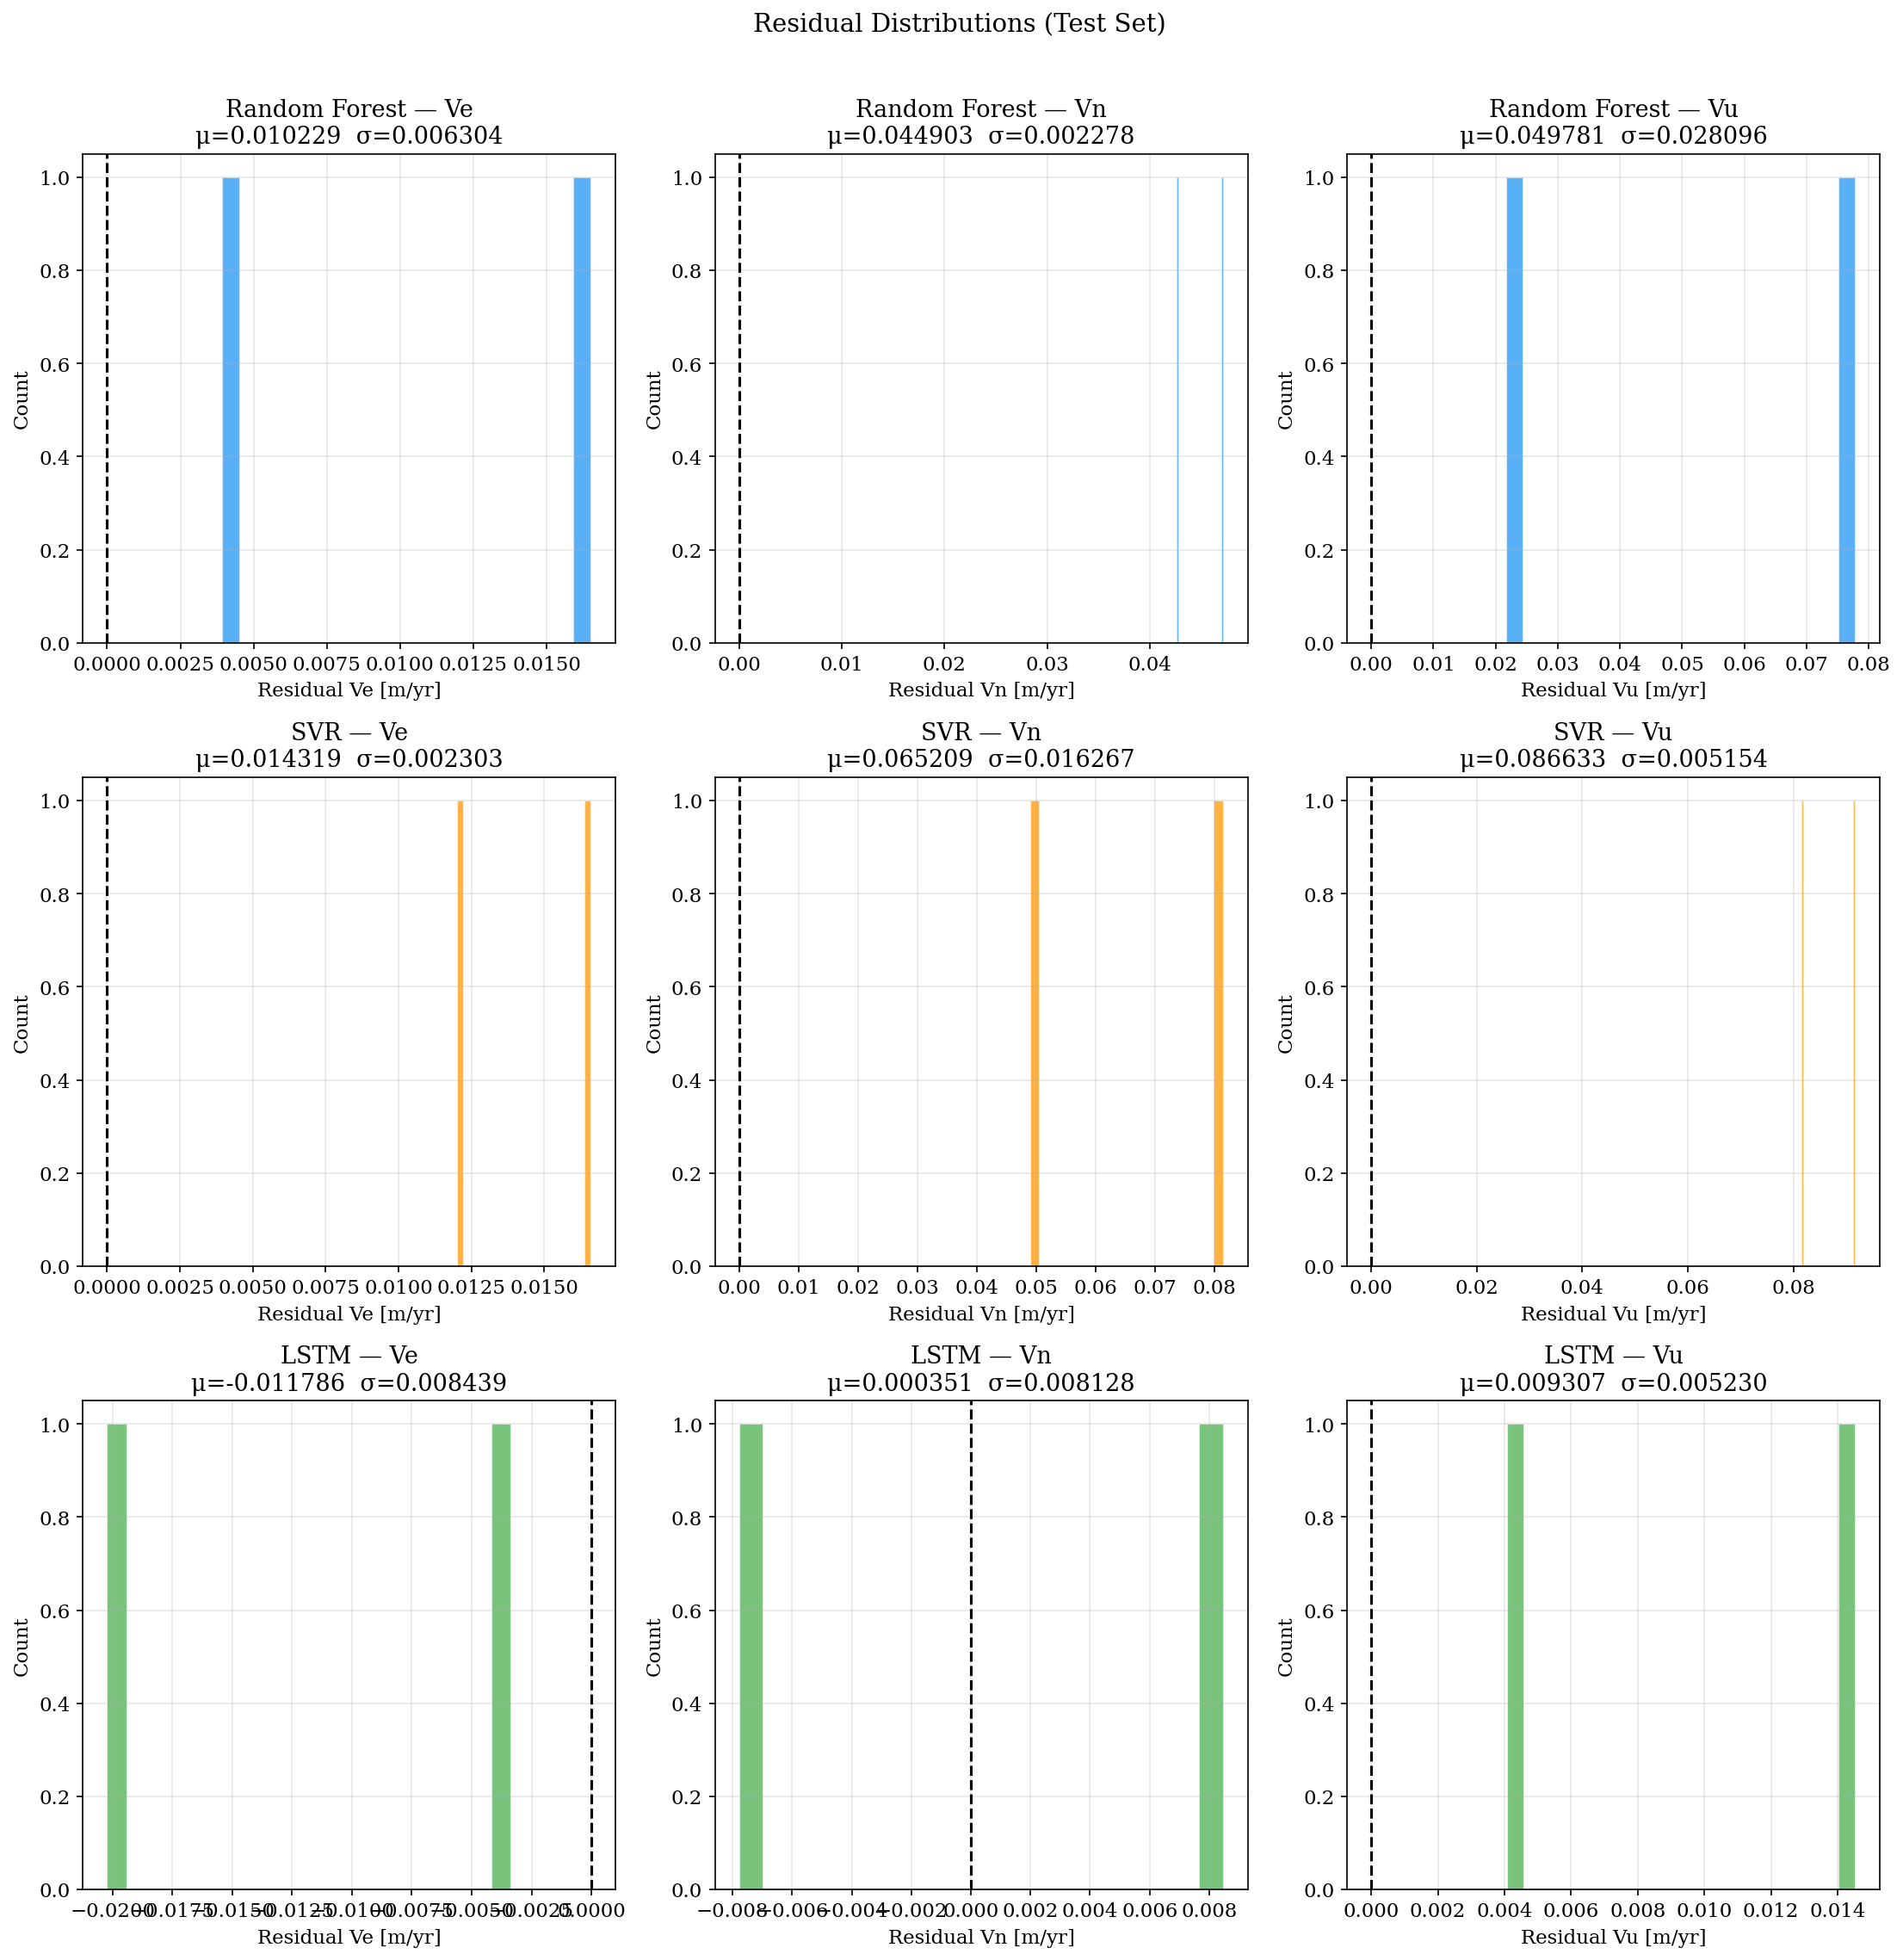

Saved: residual_distributions.png


In [21]:
fig, axes = plt.subplots(n_models, 3, figsize=(15, 5 * n_models))

for row_i, model_name in enumerate(model_names):
    pred_arr = predictions[model_name]
    color    = MODEL_COLORS[model_name]

    for col_i, comp in enumerate(components):
        ax       = axes[row_i][col_i]
        residual = y_test[comp].values - pred_arr[:, col_i]

        ax.hist(residual, bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5, ls='--')
        ax.set_xlabel(f"Residual {comp} [m/yr]")
        ax.set_ylabel("Count")
        ax.set_title(f"{model_name} — {comp}\n"
                     f"μ={residual.mean():.6f}  σ={residual.std():.6f}")

fig.suptitle("Residual Distributions (Test Set)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("residual_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: residual_distributions.png")

BLOCK 13 — PHASE 6 PLOTS: MODEL COMPARISON BAR CHART

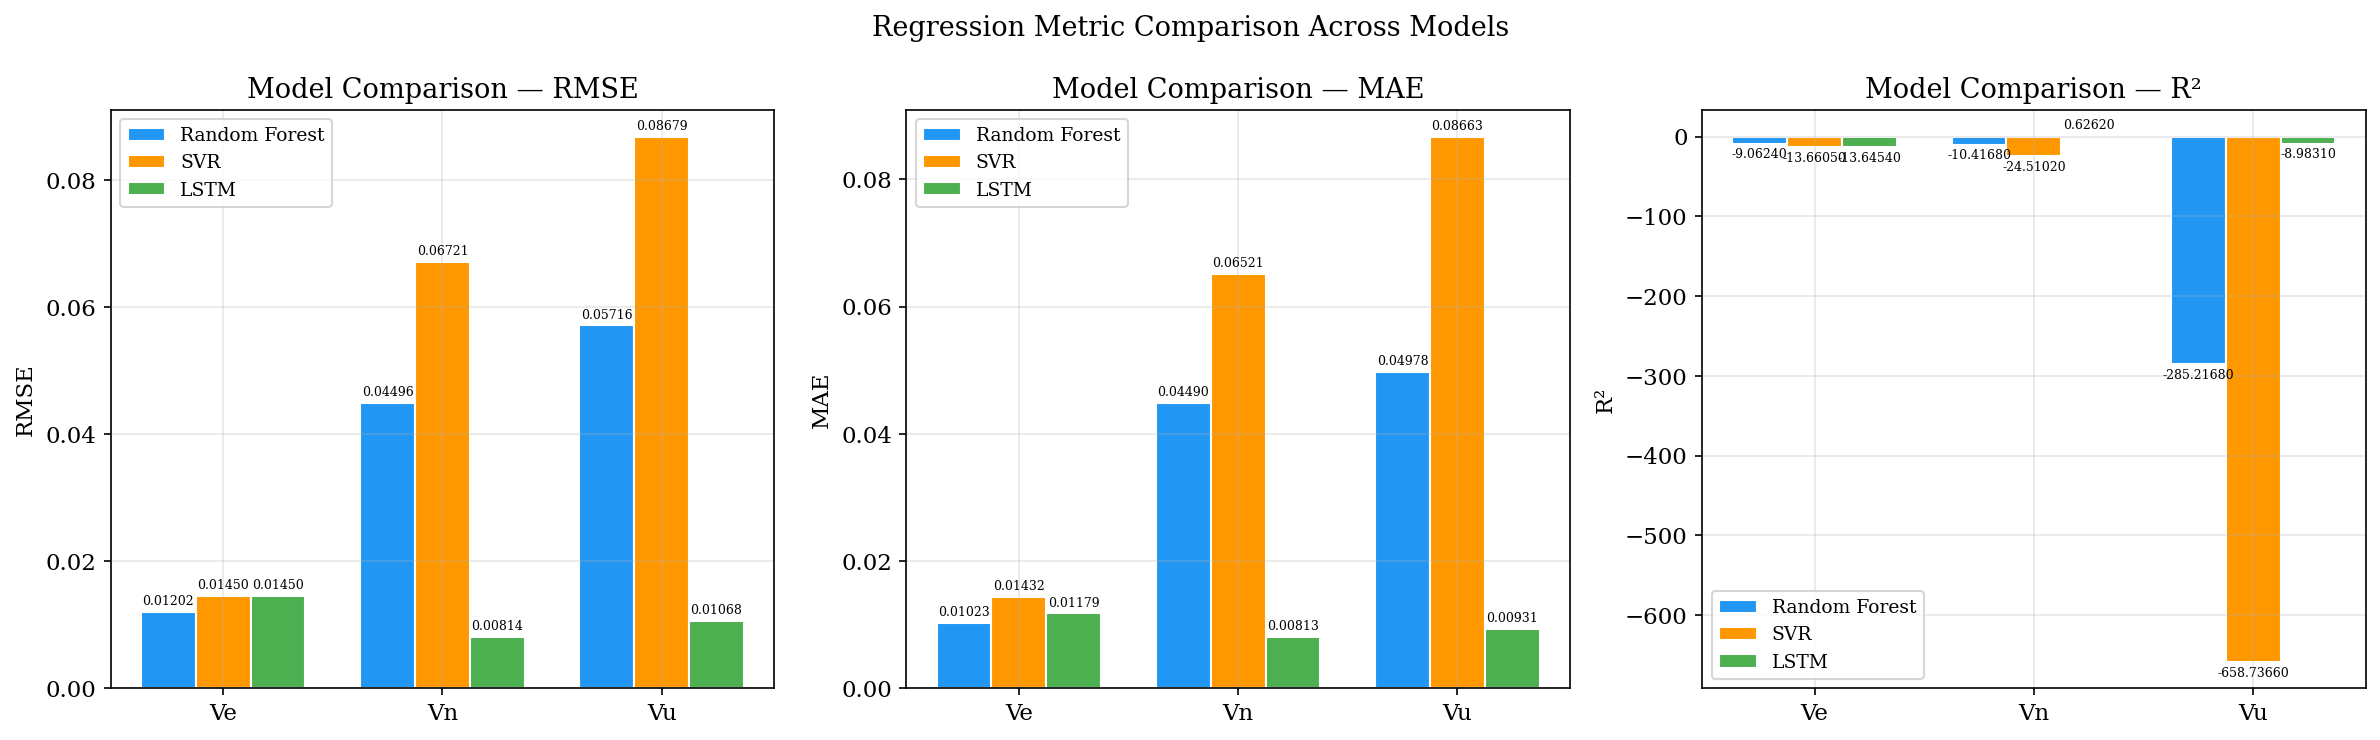

Saved: model_comparison.png


In [22]:
metric_keys = ['RMSE', 'MAE', 'R²']
fig, axes   = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metric_keys):
    x      = np.arange(len(components))
    width  = 0.25

    for i, model_name in enumerate(model_names):
        sub    = metrics_df[metrics_df['Model'] == model_name]
        values = [sub[sub['Component'] == c][metric].values[0]
                  for c in components]
        bars = ax.bar(x + i * width, values, width,
                      label=model_name,
                      color=MODEL_COLORS[model_name],
                      edgecolor='white')
        ax.bar_label(bars, fmt='%.5f', fontsize=6, padding=2)

    ax.set_xticks(x + width)
    ax.set_xticklabels(components)
    ax.set_title(f"Model Comparison — {metric}")
    ax.set_ylabel(metric)
    ax.legend()

plt.suptitle("Regression Metric Comparison Across Models", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

BLOCK 14 — PHASE 7: CLASSIFICATION DIAGNOSTICS        
(Supplementary — NOT the primary task)

In [23]:
print("=" * 55)
print("PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)")
print("=" * 55)
print("""
Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)

NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.
""")

CLASS_BINS   = [-np.inf, 0.005, 0.020, np.inf]
CLASS_LABELS = ['Stable', 'Moderate', 'Active']

def discretize_velocity(ve_arr, vn_arr):
    vmag = np.sqrt(ve_arr**2 + vn_arr**2)
    return pd.cut(vmag, bins=CLASS_BINS, labels=CLASS_LABELS)

y_true_cls = discretize_velocity(
    y_test['Ve'].values, y_test['Vn'].values)

cls_rows = []
for model_name, pred_arr in predictions.items():
    y_pred_cls = discretize_velocity(pred_arr[:, 0], pred_arr[:, 1])

    acc = accuracy_score(y_true_cls, y_pred_cls)
    p   = precision_score(y_true_cls, y_pred_cls,
                          labels=CLASS_LABELS, average='weighted',
                          zero_division=0)
    r   = recall_score(y_true_cls, y_pred_cls,
                       labels=CLASS_LABELS, average='weighted',
                       zero_division=0)
    f1  = f1_score(y_true_cls, y_pred_cls,
                   labels=CLASS_LABELS, average='weighted',
                   zero_division=0)

    print(f"\n  [{model_name}]")
    print(classification_report(y_true_cls, y_pred_cls,
                                labels=CLASS_LABELS,
                                zero_division=0))
    cls_rows.append({
        'Model'    : model_name,
        'Accuracy' : round(acc, 4),
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1-Score' : round(f1, 4),
    })

cls_df = pd.DataFrame(cls_rows)
print("\n  Summary:")
display(cls_df)
cls_df.to_csv("classification_diagnostics.csv", index=False)
print("Saved: classification_diagnostics.csv")

PHASE 7 — CLASSIFICATION DIAGNOSTICS (supplementary)

Velocity magnitude classes:
  Stable   : |V_horiz| < 0.005 m/yr  (< 5 mm/yr)
  Moderate : 0.005 ≤ |V| < 0.020 m/yr
  Active   : |V_horiz| ≥ 0.020 m/yr  (≥ 20 mm/yr)
 
NOTE: ML models are REGRESSION models. Classification is a
post-hoc discretisation for supplementary interpretation only.


  [Random Forest]
              precision    recall  f1-score   support

      Stable       0.00      0.00      0.00         0
    Moderate       0.00      0.00      0.00         1
      Active       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.17      0.33      0.22         2
weighted avg       0.25      0.50      0.33         2


  [SVR]
              precision    recall  f1-score   support

      Stable       0.00      0.00      0.00         0
    Moderate       0.00      0.00      0.00         1
      Active       0.50      1.00      0.67         1

    accuracy                 

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.5,0.25,0.5,0.3333
1,SVR,0.5,0.25,0.5,0.3333
2,LSTM,0.5,0.25,0.5,0.3333


Saved: classification_diagnostics.csv


BLOCK 15 — SELECT BEST MODEL & RE-ESTIMATE ALL STATIONS

In [24]:
# Best model = highest mean R² on Ve and Vn (horizontal components)
best_model_name = (
    metrics_df[metrics_df['Component'].isin(['Ve', 'Vn'])]
    .groupby('Model')['R²'].mean()
    .idxmax()
)
print(f"Best model selected for interpolation: {best_model_name}")

# Re-estimate velocities on ALL stations using best model
Xs_all    = scaler.transform(X)
Xs_all_3d = Xs_all.reshape((Xs_all.shape[0], 1, Xs_all.shape[1]))

if best_model_name == 'SVR':
    Ve_est = svr_models['Ve'].predict(Xs_all)
    Vn_est = svr_models['Vn'].predict(Xs_all)
    Vu_est = svr_models['Vu'].predict(Xs_all)
elif best_model_name == 'LSTM':
    preds  = lstm_model.predict(Xs_all_3d, verbose=0)
    Ve_est, Vn_est, Vu_est = preds[:, 0], preds[:, 1], preds[:, 2]
else:
    preds  = rf_model.predict(X)
    Ve_est, Vn_est, Vu_est = preds[:, 0], preds[:, 1], preds[:, 2]

vel_df['Ve_est'] = Ve_est
vel_df['Vn_est'] = Vn_est
vel_df['Vu_est'] = Vu_est

vel_df.to_csv("gnss_station_velocities_with_ml.csv", index=False)
print("Saved: gnss_station_velocities_with_ml.csv")
display(vel_df[['site', 'latitude', 'longitude',
                'Ve', 'Vn', 'Vu',
                'Ve_est', 'Vn_est', 'Vu_est']].head(10))

Best model selected for interpolation: LSTM
Saved: gnss_station_velocities_with_ml.csv


,site,latitude,longitude,Ve,Vn,Vu,Ve_est,Vn_est,Vu_est
0,DVAO,7.071865,-234.387132,-0.027744,-0.004182,-0.002869,-0.027640,0.005705,-0.009074
1,PBIS,8.189172,-233.646119,-0.030673,0.018406,-0.001030,-0.016913,-0.001123,-0.013928
2,PCOT,7.199604,-235.752967,-0.010649,-0.009260,0.000915,-0.016334,0.005641,-0.018528
3,PDAV,7.126490,-234.356595,-0.030390,-0.001656,-0.004509,-0.017213,-0.005155,-0.017284
4,PDDN,7.459377,-234.216750,-0.028949,0.000545,-0.011117,-0.018200,-0.011327,-0.017499
5,PDIP,8.586842,-236.655707,-0.006614,0.000877,0.002386,-0.006481,-0.001497,-0.000537
6,PGEN,6.064912,-234.868338,-0.010057,-0.010548,-0.003733,-0.019222,0.004910,-0.022052
7,PMAI,6.061264,-235.504403,-0.155414,-0.554815,-0.951111,-0.028149,-0.023403,-0.031973
8,PMRM,7.856279,-234.941257,-0.017386,-0.000644,0.003937,-0.008475,0.013488,-0.002882
9,PSUR,9.791809,-234.506303,-0.019155,0.027194,-0.007292,0.001070,0.018716,-0.011368


BLOCK 16 — PHASE 8: SPATIAL INTERPOLATION                   
                                                              
 Interpolates ML-estimated station velocities onto a         
 regular lon/lat grid using Ordinary Kriging (PyKrige) or    
 IDW as fallback. A continuous field is REQUIRED before      
 spatial derivatives (strain) can be computed.

In [25]:
GRID_RES = 100   # grid points per axis

lons = vel_df['longitude'].values
lats = vel_df['latitude'].values
Ve_s = vel_df['Ve_est'].values
Vn_s = vel_df['Vn_est'].values

# Build regular grid with 10% padding
pad_lon = (lons.max() - lons.min()) * 0.10 or 0.5
pad_lat = (lats.max() - lats.min()) * 0.10 or 0.5

grid_lon_1d = np.linspace(lons.min() - pad_lon, lons.max() + pad_lon, GRID_RES)
grid_lat_1d = np.linspace(lats.min() - pad_lat, lats.max() + pad_lat, GRID_RES)
grid_lon, grid_lat = np.meshgrid(grid_lon_1d, grid_lat_1d)

print("=" * 55)
print("PHASE 8 — SPATIAL INTERPOLATION")
print("=" * 55)

if PYKRIGE_AVAILABLE:
    print("  Method : Ordinary Kriging (PyKrige, spherical variogram)")
    ok_Ve = OrdinaryKriging(lons, lats, Ve_s,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    ok_Vn = OrdinaryKriging(lons, lats, Vn_s,
                            variogram_model='spherical',
                            verbose=False, enable_plotting=False)
    Ve_grid, _ = ok_Ve.execute('grid', grid_lon_1d, grid_lat_1d)
    Vn_grid, _ = ok_Vn.execute('grid', grid_lon_1d, grid_lat_1d)
    Ve_grid = np.array(Ve_grid)
    Vn_grid = np.array(Vn_grid)
    print("  Kriging complete.")

else:
    print("  Method : IDW (Inverse Distance Weighting, power=2)")

    def idw_interpolate(lons_s, lats_s, values, glon, glat, power=2):
        from sklearn.neighbors import BallTree
        pts    = np.column_stack([lons_s, lats_s])
        gpts   = np.column_stack([glon.ravel(), glat.ravel()])
        tree   = BallTree(np.deg2rad(pts), metric='haversine')
        dist, idx = tree.query(np.deg2rad(gpts), k=min(8, len(pts)))
        dist   = np.where(dist == 0, 1e-10, dist)
        w      = 1.0 / dist**power
        vals   = values[idx]
        result = (w * vals).sum(axis=1) / w.sum(axis=1)
        return result.reshape(glon.shape)

    Ve_grid = idw_interpolate(lons, lats, Ve_s, grid_lon, grid_lat)
    Vn_grid = idw_interpolate(lons, lats, Vn_s, grid_lon, grid_lat)
    print("  IDW complete.")

print(f"  Grid shape : {Ve_grid.shape}")
print(f"  Ve range   : {Ve_grid.min():.6f} → {Ve_grid.max():.6f} m/yr")
print(f"  Vn range   : {Vn_grid.min():.6f} → {Vn_grid.max():.6f} m/yr")

PHASE 8 — SPATIAL INTERPOLATION
  Method : Ordinary Kriging (PyKrige, spherical variogram)
  Kriging complete.
  Grid shape : (100, 100)
  Ve range   : -0.025631 → -0.001080 m/yr
  Vn range   : -0.016881 → 0.014575 m/yr


BLOCK 17 — PHASE 8 PLOT: VELOCITY FIELD MAP

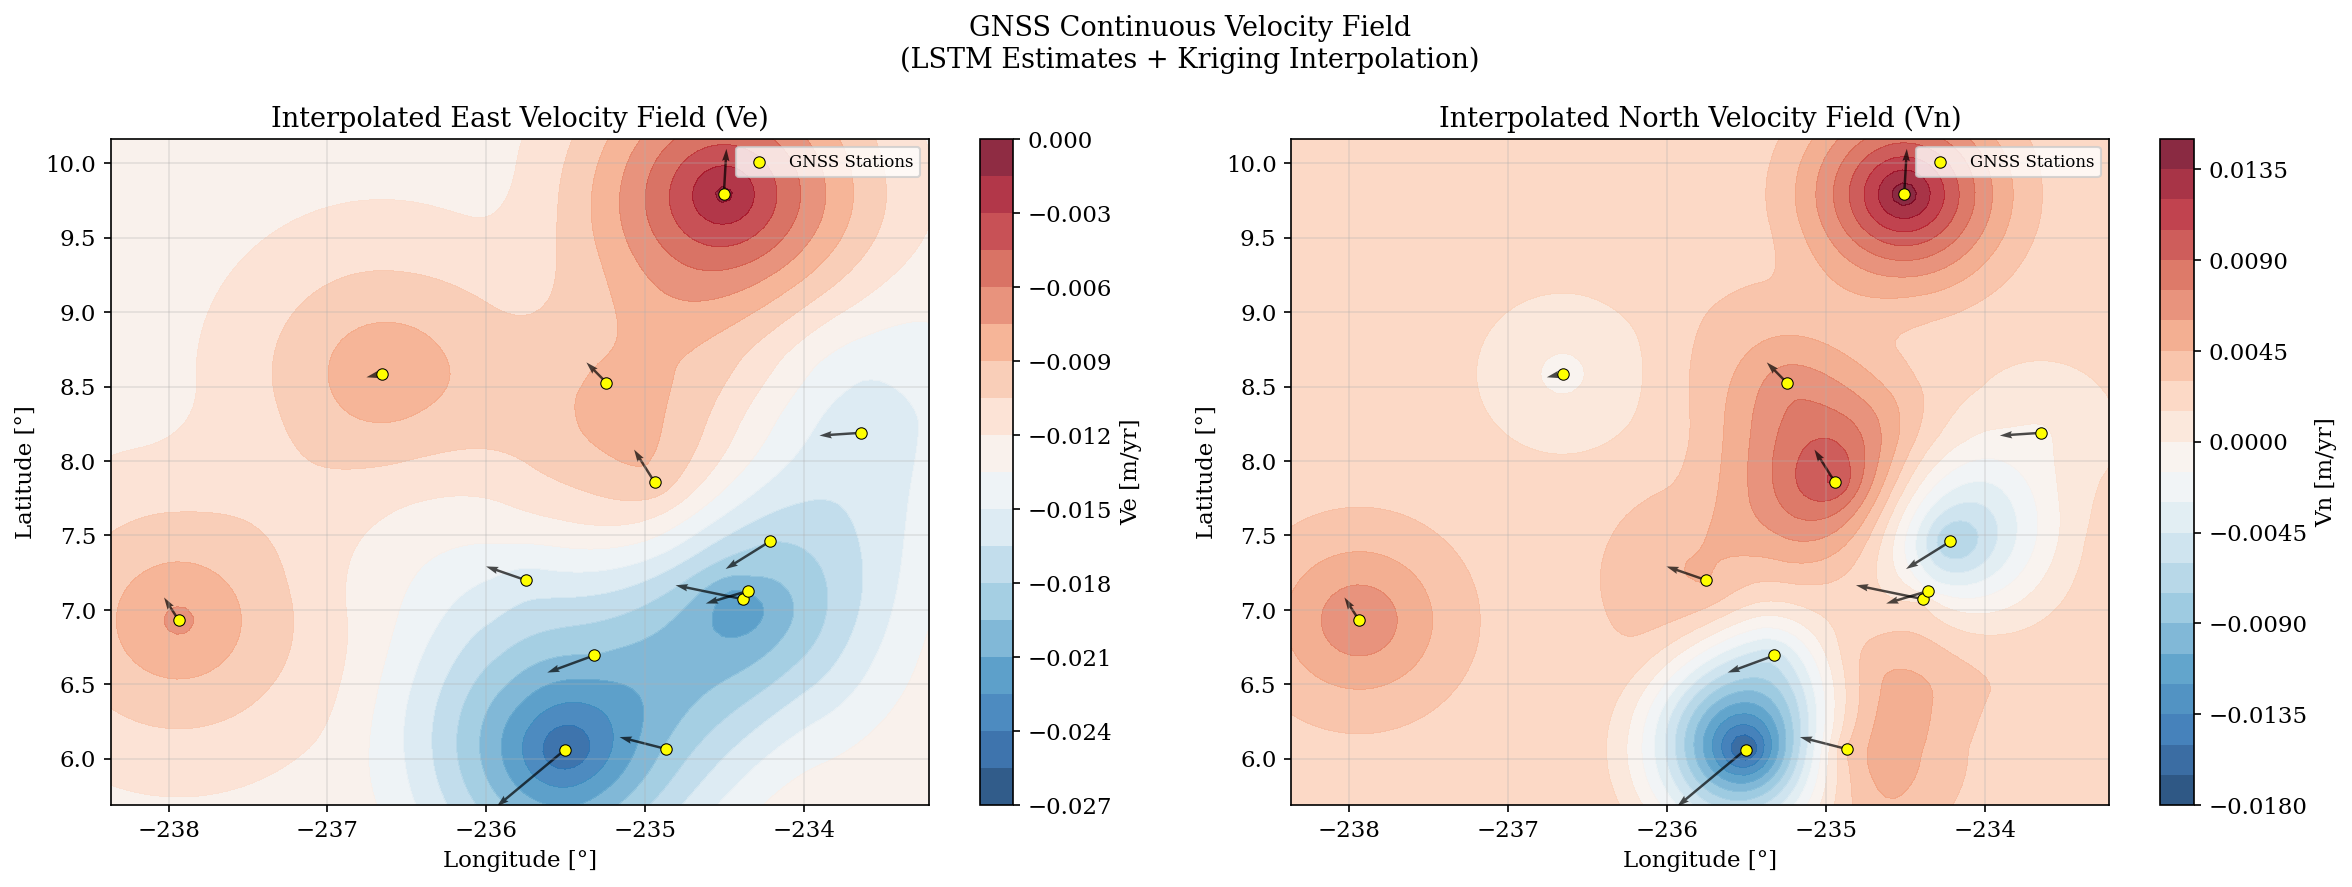

Saved: velocity_field_map.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── East velocity ──────────────────────────────────────────────
ax = axes[0]
cf = ax.contourf(grid_lon, grid_lat, Ve_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Ve [m/yr]')
ax.quiver(lons, lats, vel_df['Ve_est'].values, vel_df['Vn_est'].values,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons, lats, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated East Velocity Field (Ve)")
ax.set_xlabel("Longitude [°]"); ax.set_ylabel("Latitude [°]")
ax.legend(fontsize=8)

# ── North velocity ─────────────────────────────────────────────
ax = axes[1]
cf = ax.contourf(grid_lon, grid_lat, Vn_grid,
                 levels=20, cmap='RdBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='Vn [m/yr]')
ax.quiver(lons, lats, vel_df['Ve_est'].values, vel_df['Vn_est'].values,
          color='black', alpha=0.7, width=0.003, scale=None)
ax.scatter(lons, lats, c='yellow', s=30, zorder=5,
           edgecolors='k', lw=0.5, label='GNSS Stations')
ax.set_title("Interpolated North Velocity Field (Vn)")
ax.set_xlabel("Longitude [°]"); ax.set_ylabel("Latitude [°]")
ax.legend(fontsize=8)

plt.suptitle(f"GNSS Continuous Velocity Field\n"
             f"({best_model_name} Estimates + Kriging Interpolation)",
             fontsize=13)
plt.tight_layout()
plt.savefig("velocity_field_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: velocity_field_map.png")

BLOCK 18 — PHASE 9: STRAIN TENSOR COMPUTATION               
                                                              
  Horizontal strain rate tensor from spatial derivatives of   
  the interpolated velocity field.                            
                                                              
  ε_xx = ∂Ve/∂x   (east–east normal strain rate)            
  ε_yy = ∂Vn/∂y   (north–north normal strain rate)          
  ε_xy = ½(∂Ve/∂y + ∂Vn/∂x)  (shear strain rate)           
                                                              
  Derived:                                                    
    Dilatation  Δ = ε_xx + ε_yy                              
    Max Shear   γ = ½√((ε_xx−ε_yy)² + 4ε_xy²)              
    2nd Invariant I₂ = √(ε_xx²+ε_yy²+2ε_xy²)               
                                                              
  Units output: nanostrain/yr (1 nstr = 1e-9 yr⁻¹)

In [27]:
print("=" * 55)
print("PHASE 9 — STRAIN TENSOR COMPUTATION")
print("=" * 55)

# ── Convert grid spacing degrees → metres ──────────────────────
R_EARTH      = 6_371_000.0
lat_mean_rad = np.deg2rad(np.mean(grid_lat))
m_per_deg_lat = np.pi * R_EARTH / 180.0
m_per_deg_lon = m_per_deg_lat * np.cos(lat_mean_rad)

dlat_m = abs(grid_lat[1, 0] - grid_lat[0, 0]) * m_per_deg_lat
dlon_m = abs(grid_lon[0, 1] - grid_lon[0, 0]) * m_per_deg_lon

# ── Spatial partial derivatives (numpy central differences) ────
# grid axis-0 = latitude (N), axis-1 = longitude (E)
dVe_dy, dVe_dx = np.gradient(Ve_grid, dlat_m, dlon_m)
dVn_dy, dVn_dx = np.gradient(Vn_grid, dlat_m, dlon_m)

epsilon_xx = dVe_dx                              # ∂Ve/∂x
epsilon_yy = dVn_dy                              # ∂Vn/∂y
epsilon_xy = 0.5 * (dVe_dy + dVn_dx)            # shear

dilatation  = epsilon_xx + epsilon_yy
max_shear   = 0.5 * np.sqrt((epsilon_xx - epsilon_yy)**2
                             + 4 * epsilon_xy**2)
second_inv  = np.sqrt(epsilon_xx**2 + epsilon_yy**2
                      + 2 * epsilon_xy**2)

# ── Convert to nanostrain/yr ───────────────────────────────────
NANO = 1e9
strain = {
    'epsilon_xx' : epsilon_xx  * NANO,
    'epsilon_yy' : epsilon_yy  * NANO,
    'epsilon_xy' : epsilon_xy  * NANO,
    'dilatation' : dilatation  * NANO,
    'max_shear'  : max_shear   * NANO,
    'second_inv' : second_inv  * NANO,
}

# Save grids
np.savez("strain_tensor_grids.npz",
         grid_lon=grid_lon, grid_lat=grid_lat,
         **strain)

print("  Strain tensor summary [nanostrain/yr]:")
for key, arr in strain.items():
    print(f"    {key:14s}  min={arr.min():+10.4f}  "
          f"max={arr.max():+10.4f}  mean={arr.mean():+10.4f}")
print()
print("Saved: strain_tensor_grids.npz")

PHASE 9 — STRAIN TENSOR COMPUTATION
  Strain tensor summary [nanostrain/yr]:
    epsilon_xx      min= -109.8618  max= +125.1323  mean=   -3.1305
    epsilon_yy      min= -281.0398  max= +200.0603  mean=   +4.5383
    epsilon_xy      min= -126.3677  max= +149.9740  mean=   +3.6770
    dilatation      min= -284.1983  max= +196.9471  mean=   +1.4078
    max_shear       min=   +0.0000  max= +186.4477  mean=  +38.6724
    second_inv      min=   +0.0000  max= +290.1023  mean=  +63.7765

Saved: strain_tensor_grids.npz


BLOCK 19 — PHASE 10 PLOT: STRAIN MAPS

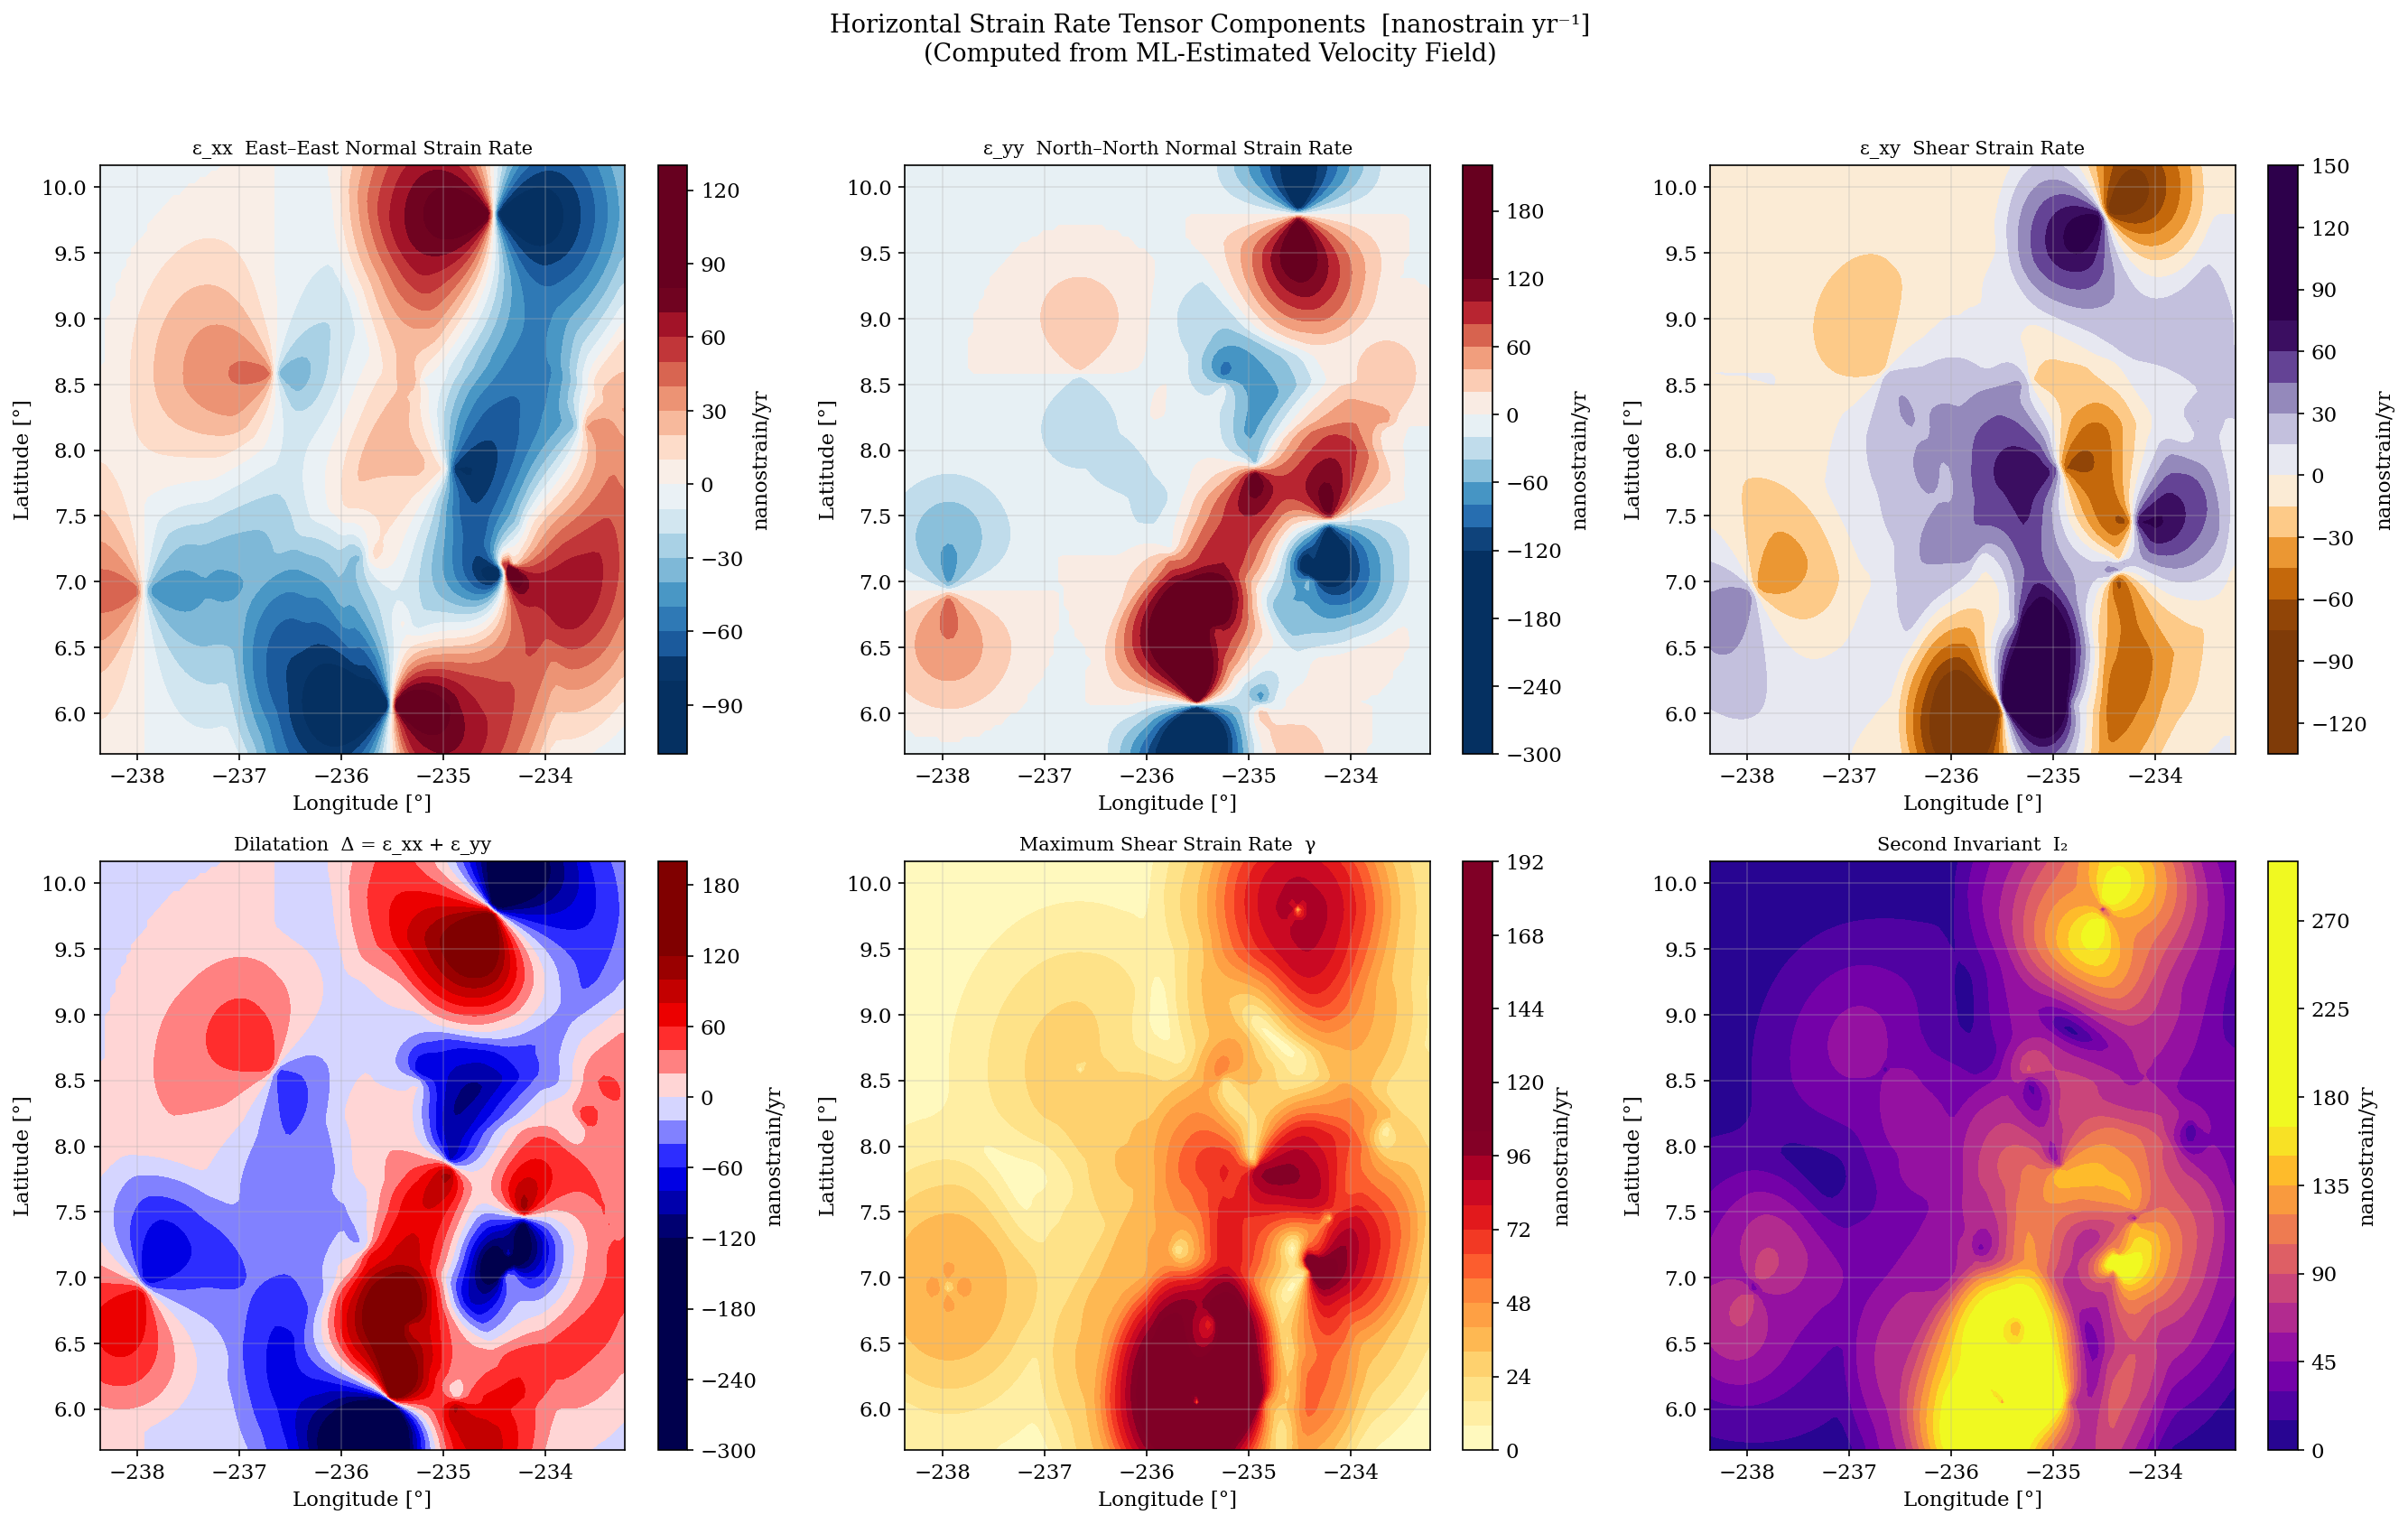

Saved: strain_maps.png


In [28]:
fields = [
    ('epsilon_xx', 'ε_xx  East–East Normal Strain Rate',    'RdBu_r'),
    ('epsilon_yy', 'ε_yy  North–North Normal Strain Rate',  'RdBu_r'),
    ('epsilon_xy', 'ε_xy  Shear Strain Rate',               'PuOr'),
    ('dilatation', 'Dilatation  Δ = ε_xx + ε_yy',          'seismic'),
    ('max_shear',  'Maximum Shear Strain Rate  γ',           'YlOrRd'),
    ('second_inv', 'Second Invariant  I₂',                  'plasma'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (key, title, cmap) in zip(axes, fields):
    data = strain[key]
    vmax = np.percentile(np.abs(data), 95)
    vmin = -vmax if cmap in ('RdBu_r', 'PuOr', 'seismic') else 0

    cf = ax.contourf(grid_lon, grid_lat, data,
                     levels=25, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(cf, ax=ax, label='nanostrain/yr')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Longitude [°]")
    ax.set_ylabel("Latitude [°]")

plt.suptitle("Horizontal Strain Rate Tensor Components  [nanostrain yr⁻¹]\n"
             "(Computed from ML-Estimated Velocity Field)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("strain_maps.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: strain_maps.png")

BLOCK 20 — FINAL SUMMARY

In [29]:
print("█" * 60)
print("  PIPELINE COMPLETE — ALL OUTPUTS GENERATED")
print("█" * 60)

print("\n── Regression Metrics Summary ──────────────────────────")
display(metrics_df.pivot_table(
    index='Model', columns='Component', values=['RMSE', 'MAE', 'R²']
).round(5))

print("\n── Classification Diagnostics Summary ──────────────────")
display(cls_df)

print("\n── Files Saved ─────────────────────────────────────────")
output_files = [
    "gnss_station_velocities.csv",
    "gnss_station_velocities_with_ml.csv",
    "regression_metrics.csv",
    "classification_diagnostics.csv",
    "strain_tensor_grids.npz",
    "rf_feature_importance.png",
    "lstm_training_curves.png",
    "actual_vs_estimated.png",
    "residual_distributions.png",
    "model_comparison.png",
    "velocity_field_map.png",
    "strain_maps.png",
]
for f in output_files:
    print(f"  ✓  {f}")

████████████████████████████████████████████████████████████
  PIPELINE COMPLETE — ALL OUTPUTS GENERATED
████████████████████████████████████████████████████████████

── Regression Metrics Summary ──────────────────────────


MAE                       RMSE                         R²  \
Component           Ve       Vn       Vu       Ve       Vn       Vu       Ve   
Model                                                                          
LSTM           0.01179  0.00813  0.00931  0.01450  0.00814  0.01068 -13.6454   
Random Forest  0.01023  0.04490  0.04978  0.01202  0.04496  0.05716  -9.0624   
SVR            0.01432  0.06521  0.08663  0.01450  0.06721  0.08679 -13.6605   

                                  
Component           Vn        Vu  
Model                             
LSTM            0.6262   -8.9831  
Random Forest -10.4168 -285.2168  
SVR           -24.5102 -658.7366


── Classification Diagnostics Summary ──────────────────


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.5,0.25,0.5,0.3333
1,SVR,0.5,0.25,0.5,0.3333
2,LSTM,0.5,0.25,0.5,0.3333



── Files Saved ─────────────────────────────────────────
  ✓  gnss_station_velocities.csv
  ✓  gnss_station_velocities_with_ml.csv
  ✓  regression_metrics.csv
  ✓  classification_diagnostics.csv
  ✓  strain_tensor_grids.npz
  ✓  rf_feature_importance.png
  ✓  lstm_training_curves.png
  ✓  actual_vs_estimated.png
  ✓  residual_distributions.png
  ✓  model_comparison.png
  ✓  velocity_field_map.png
  ✓  strain_maps.png
